# 01 - Exploratory Data Analysis
**Women's Clothing E-Commerce Reviews** - 23,486 anonymized real customer reviews. This project keys off a single column, `Review Text`. The other columns are not a prediction target; they are the *labels we happen to have* (`Recommended IND`, `Department Name`, `Rating`) that later let us check, honestly, whether the review embeddings are meaningful.

This notebook just looks at the data.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, matplotlib.pyplot as plt
from src.data import load_raw, load_reviews
raw = load_raw(); df = load_reviews()
print(f'raw rows: {len(raw):,}   usable reviews after cleaning: {len(df):,}')
df[['Review Text','Rating','Recommended IND','Department Name','Class Name']].head()

raw rows: 23,486   usable reviews after cleaning: 22,634


,Review Text,Rating,Recommended IND,Department Name,Class Name
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate,Intimates
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses,Dresses
2,I had such high hopes for this dress and reall...,3,0,Dresses,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms,Pants
4,This shirt is very flattering to all due to th...,5,1,Tops,Blouses


### How much usable text is there?
A few hundred rows have no review text, and a handful of exact duplicates are dropped so they can't dominate a 'most similar' result.

In [2]:
missing = raw['Review Text'].isna().sum()
dupes = raw['Review Text'].dropna().duplicated().sum()
print(f'rows with no review text : {missing:,}')
print(f'exact duplicate texts    : {dupes:,}')
print(f'kept for analysis        : {len(df):,}')

rows with no review text : 845
exact duplicate texts    : 7
kept for analysis        : 22,634


### Sentiment is heavily positive
Ratings skew high and ~82% of reviews recommend the product - worth remembering when we read the sentiment probe later (a majority-class guess already scores ~0.82).

share recommending: 0.819


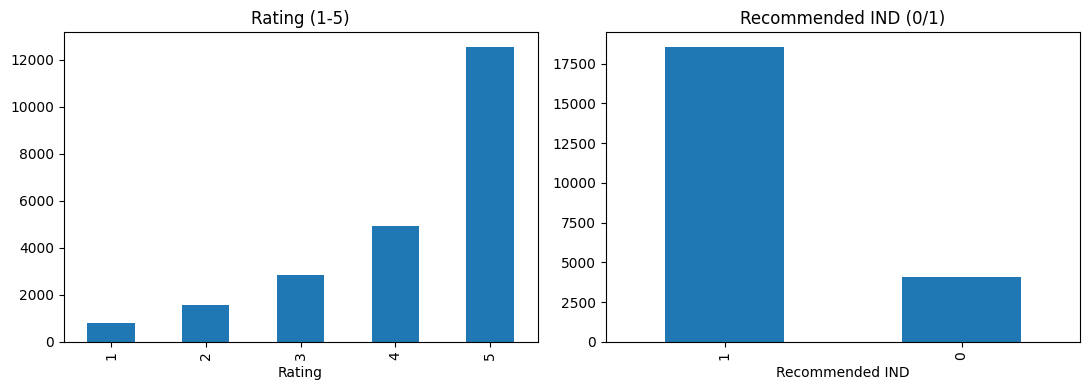

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['Rating'].value_counts().sort_index().plot.bar(ax=ax[0], title='Rating (1-5)')
df['Recommended IND'].value_counts().plot.bar(ax=ax[1], title='Recommended IND (0/1)')
print('share recommending:', round(df['Recommended IND'].mean(), 3))
plt.tight_layout(); plt.show()

### What product areas do reviews cover?

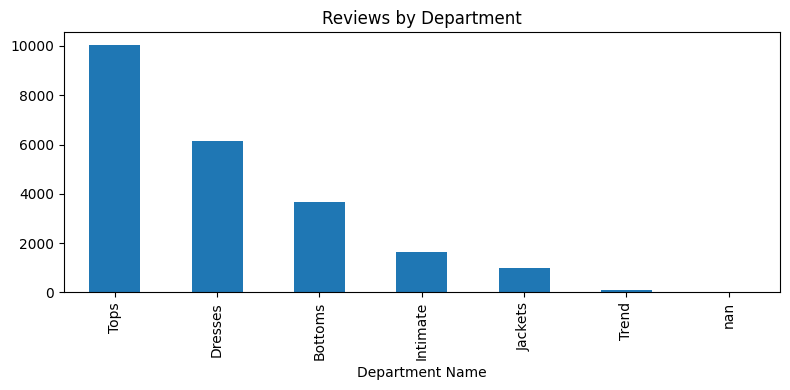

Department Name
Tops        0.444
Dresses     0.272
Bottoms     0.162
Intimate    0.073
Jackets     0.044
Trend       0.005
Name: proportion, dtype: float64

In [4]:
df['Department Name'].value_counts(dropna=False).plot.bar(
    figsize=(8,4), title='Reviews by Department'); plt.tight_layout(); plt.show()
df['Department Name'].value_counts(normalize=True).round(3)

### Review length
Most reviews are short (a sentence or two) - which is exactly why a TF-IDF bag-of-words baseline turns out to be a tough opponent on sentiment in notebook 02.

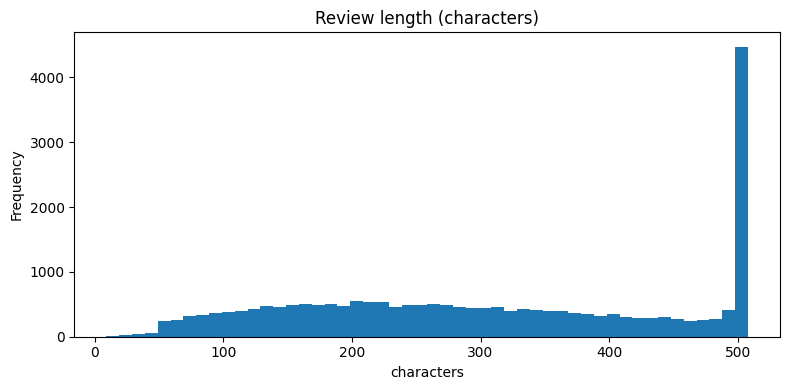

count    22634.0
mean       308.7
std        143.9
min          9.0
25%        186.0
50%        301.0
75%        458.8
max        508.0
Name: review_length, dtype: Float64

In [5]:
df['review_length'].plot.hist(bins=50, figsize=(8,4),
    title='Review length (characters)'); plt.xlabel('characters'); plt.tight_layout(); plt.show()
df['review_length'].describe().round(1)

**Takeaway.** Clean, mostly-positive, short product reviews across six departments. Next: embed the `Review Text`, map the topics, triage them, and test whether the embedding space actually encodes sentiment and product area.